In [1]:
import json
import pickle
from argparse import ArgumentParser
from typing import List, Dict, Tuple
import clip
import numpy as np
import torch
import torch.nn.functional as F
from clip.model import CLIP
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from tqdm import tqdm
from data_utils import collate_fn, PROJECT_ROOT, targetpad_transform
from datasets import CIRCODataset
from utils import extract_image_features

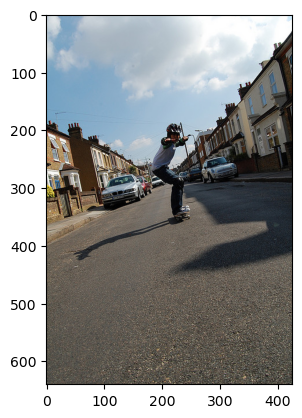

In [2]:
from PIL import Image
from transformers import BitsAndBytesConfig as TransformersBitsAndBytesConfig
from transformers import Qwen2_5_VLForConditionalGeneration
from diffusers import BitsAndBytesConfig as DiffusersBitsAndBytesConfig
from diffusers import QwenImagePipeline, QwenImageTransformer2DModel, QwenImageEditPipeline

import torch
import gc

import matplotlib.image as mpimg
import matplotlib.pyplot as plt

reference_img = mpimg.imread('../../data_CIR/CIRCO/COCO2017_unlabeled/unlabeled2017/000000247405.jpg')
plt.imshow(reference_img)

## 1. Mental Image Generation

In [ ]:
model_id = "Qwen/Qwen-Image-Edit"
torch_dtype = torch.bfloat16
device = "cuda"

quantization_config = DiffusersBitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    llm_int8_skip_modules=["transformer_blocks.0.img_mod"],
)

transformer = QwenImageTransformer2DModel.from_pretrained(
        model_id,
        subfolder="transformer",
        quantization_config=quantization_config,
        torch_dtype=torch_dtype,
    )
transformer = transformer.to("cpu")

quantization_config = TransformersBitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

text_encoder = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    subfolder="text_encoder",
    quantization_config=quantization_config,
    torch_dtype=torch_dtype,
)
text_encoder = text_encoder.to("cpu")

pipe = QwenImageEditPipeline.from_pretrained(
    model_id,
    transformer=transformer,
    text_encoder=text_encoder,
    torch_dtype=torch_dtype,
    local_files_only=True,
)
pipe.enable_model_cpu_offload()

image = Image.open('../../data_CIR/CIRCO/COCO2017_unlabeled/unlabeled2017/000000247405.jpg')
prompt = f"Edit the image according to the following instruction: is keeping one dog on a leash and the dog is next to them, while strictly preserving 'a person skateboarding' in the image."
inputs = {
            "image": image,
            "prompt": prompt,
            "generator": torch.manual_seed(0),
            "true_cfg_scale": 4.0,
            "negative_prompt": " ",
            "num_inference_steps": 50,
            "width": 512,
            "height": 512
        }

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/9 [00:00<?, ?it/s]

`low_cpu_mem_usage` was None, now default to True since model is quantized.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

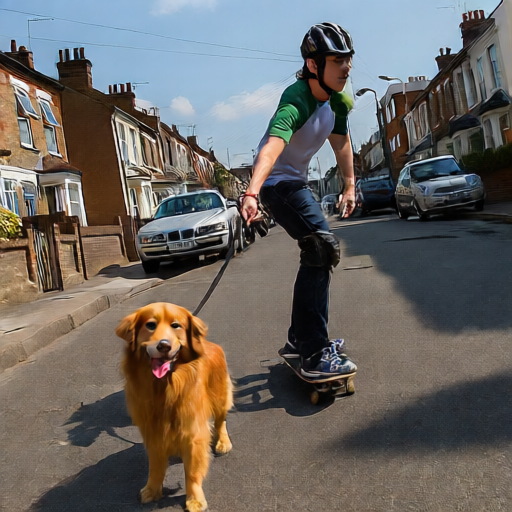

In [4]:
with torch.inference_mode():
    output = pipe(**inputs)
    mental_img = output.images[0]
mental_img

## 2. Description Generation

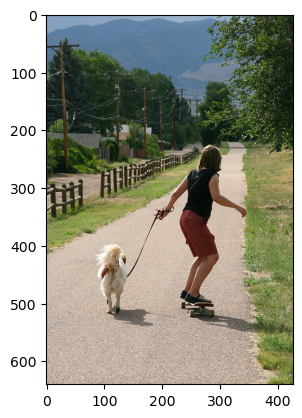

In [5]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoTokenizer, AutoProcessor
from qwen_vl_utils import process_vision_info

candidate_img = mpimg.imread('../../data_CIR/CIRCO/COCO2017_unlabeled/unlabeled2017/000000256167.jpg')
plt.imshow(candidate_img)

In [6]:
model = Qwen2_5_VLForConditionalGeneration.from_pretrained("Qwen/Qwen2.5-VL-7B-Instruct", torch_dtype=torch.bfloat16, device_map="cuda")
processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-7B-Instruct")

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [7]:
messages = [
    {"role": "user",
     "content": [
         {"type": "image",
          "image": '../../data_CIR/CIRCO/COCO2017_unlabeled/unlabeled2017/000000256167.jpg', },
         {"type": "text",
          "text": 'You are an image description expert. You are given an original image. Your goal is to generate an image description that ensures the original image description is thorough, capturing all visible objects, attributes, and elements. The original image description should be as accurate as possible, reflecting the content of the image.'}, ],
    }
]
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(text=[text], images=image_inputs, padding=True, return_tensors="pt", )
inputs = inputs.to("cuda")
generated_ids = model.generate(**inputs, max_new_tokens=256)
generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)
detailed_des_candidate_img = output_text[0]
detailed_des_candidate_img

'The image depicts a person skateboarding on a paved path in a suburban or rural setting. The individual is wearing a sleeveless black top and red shorts, with dark shoes. They are holding a leash attached to a small, fluffy white dog, which appears to be a breed like a Shih Tzu or a similar small dog. The path is bordered by grassy areas on both sides, with wooden fences lining one side. In the background, there are trees, utility poles with wires, and a distant view of mountains under a clear sky. The overall atmosphere suggests a peaceful, sunny day.'

In [8]:
messages = [
    {"role": "user",
     "content": [
         {"type": "image",
          "image": mental_img, },
         {"type": "text",
          "text": 'You are an image description expert. You are given an original image. The image description only contains the image content and needs to be as simple as possible. Minimize aesthetic descriptions as much as possible. You must describe the image in one sentence.'}, ],
    }
]

text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(text=[text], images=image_inputs, padding=True, return_tensors="pt", )
inputs = inputs.to("cuda")
generated_ids = model.generate(**inputs, max_new_tokens=256)
generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)
des_mental_img = output_text[0]
des_mental_img

'A person wearing a helmet is skateboarding on a street, with a dog standing nearby.'

## 3. Synthetic Counterpart Generation

In [9]:
from transformers import BitsAndBytesConfig as TransformersBitsAndBytesConfig
from transformers import Qwen2_5_VLForConditionalGeneration
from diffusers import BitsAndBytesConfig as DiffusersBitsAndBytesConfig
from diffusers import QwenImagePipeline, QwenImageTransformer2DModel
del model, processor
torch.cuda.empty_cache()

In [10]:
model_id = "Qwen/Qwen-Image"
torch_dtype = torch.bfloat16
device = "cuda"

pipe = QwenImagePipeline.from_pretrained(
    model_id,
    transformer=transformer,
    torch_dtype=torch_dtype,
    local_files_only=True,
)
pipe.enable_model_cpu_offload()

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

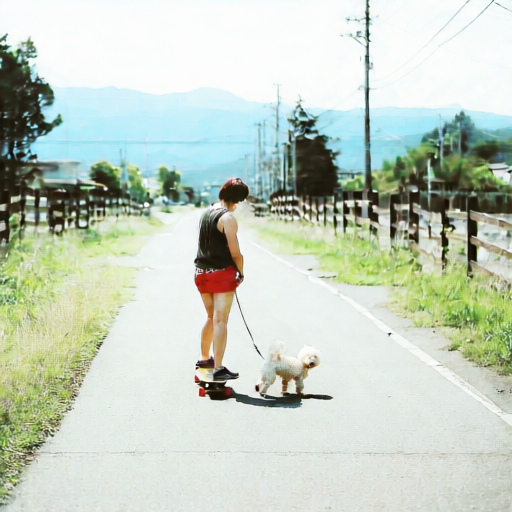

In [11]:
synthetic_image = pipe(
    prompt=detailed_des_candidate_img,
    negative_prompt=' ',
    width=512,
    height=512,
    num_inference_steps=50,
    true_cfg_scale=4.0,
    generator=torch.Generator(device="cuda").manual_seed(42)
).images[0]
synthetic_image

In [12]:
del pipe, transformer, quantization_config, text_encoder
gc.collect()
torch.cuda.empty_cache()

## 4. CIR Demo

In [13]:
def circo_generate_val_predictions(clip_model, relative_val_dataset, lam):
    relative_val_loader = DataLoader(dataset=relative_val_dataset, batch_size=32, num_workers=10, pin_memory=False, collate_fn=collate_fn, shuffle=False)

    predicted_features_list = []
    target_names_list = []
    gts_img_ids_list = []

    for batch in tqdm(relative_val_loader):
        target_names = batch['target_name']
        gt_img_ids = batch['gt_img_ids']
        
        mental_images = batch['mental_images'].to(device)
        mental_images_des = batch['mental_images_des']
        mental_images_des = clip.tokenize(mental_images_des, context_length=77, truncate=True).to(device)
        
        mod_text = batch['mod_text']
        mod_text = clip.tokenize(mod_text, context_length=77, truncate=True).to(device)

        gt_img_ids = np.array(gt_img_ids).T.tolist()

        with torch.no_grad():
            mental_images_feature = clip_model.encode_image(mental_images)
            mental_images_des_feature = clip_model.encode_text(mental_images_des)
            mod_text_feature = clip_model.encode_text(mod_text)

        mental_features = lam * F.normalize(mental_images_feature + mental_images_des_feature)
        mod_text_features = (1 - lam) * mod_text_feature
        predicted_features = mental_features + mod_text_features
            
        predicted_features_list.append(predicted_features)
        target_names_list.extend(target_names)
        gts_img_ids_list.extend(gt_img_ids)

    predicted_features = torch.vstack(predicted_features_list)
    return predicted_features, target_names_list, gts_img_ids_list

In [14]:
def circo_compute_val_metrics(relative_val_dataset, clip_model, index_features, index_names, lamd):
    predicted_features, target_names, gts_img_ids = circo_generate_val_predictions(clip_model, relative_val_dataset, lamd)

    ap_at5 = []
    ap_at10 = []
    ap_at25 = []
    ap_at50 = []

    index_features = index_features.to(device)
    predicted_features = predicted_features.to(device)

    for predicted_feature, target_name, gt_img_ids in tqdm(zip(predicted_features, target_names, gts_img_ids)):
        gt_img_ids = np.array(gt_img_ids)[np.array(gt_img_ids) != '']
        similarity = predicted_feature @ index_features.T
        sorted_indices = torch.topk(similarity, dim=-1, k=50).indices.cpu()
        sorted_index_names = np.array(index_names)[sorted_indices]
        map_labels = torch.tensor(np.isin(sorted_index_names, gt_img_ids), dtype=torch.uint8)
        precisions = torch.cumsum(map_labels, dim=0) * map_labels
        precisions = precisions / torch.arange(1, map_labels.shape[0] + 1)
        
        ap_at5.append(float(torch.sum(precisions[:5]) / min(len(gt_img_ids), 5)))
        ap_at10.append(float(torch.sum(precisions[:10]) / min(len(gt_img_ids), 10)))
        ap_at25.append(float(torch.sum(precisions[:25]) / min(len(gt_img_ids), 25)))
        ap_at50.append(float(torch.sum(precisions[:50]) / min(len(gt_img_ids), 50)))

    map_at5 = np.mean(ap_at5) * 100
    map_at10 = np.mean(ap_at10) * 100
    map_at25 = np.mean(ap_at25) * 100
    map_at50 = np.mean(ap_at50) * 100
    
    return {
        'circo_val_map_at5': map_at5,
        'circo_val_map_at10': map_at10,
        'circo_val_map_at25': map_at25,
        'circo_val_map_at50': map_at50,
    }


In [15]:
def circo_val_retrieval(dataset_path, clip_model, preprocess, lamd):
    classic_val_dataset = CIRCODataset(dataset_path, 'val', 'classic', preprocess)
    index_features, index_names = extract_image_features(classic_val_dataset, clip_model)

    relative_val_dataset = CIRCODataset(dataset_path, 'val', 'relative', preprocess)

    return circo_compute_val_metrics(relative_val_dataset, clip_model, index_features, index_names, lamd)

In [16]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
def main():
    dataset_path = "../../data_CIR/CIRCO/"
    
    clip_model, clip_preprocess = clip.load('ViT-B/32', device=device, jit=False)
    clip_model = clip_model.eval().requires_grad_(False).to(device)
    preprocess = targetpad_transform(1.25, clip_model.visual.input_resolution)

    circo_metrics = circo_val_retrieval(dataset_path, clip_model, preprocess, lamd=0.3)

    for k, v in circo_metrics.items():
        print(f"{k} = {v:.2f}")

In [17]:
if __name__ == '__main__':
    main()

CIRCODataset val dataset in classic mode initialized
extracting image features CIRCODataset - val


100%|███████████████████████████████████████| 3857/3857 [04:35<00:00, 14.02it/s]


CIRCODataset val dataset in relative mode initialized


100%|█████████████████████████████████████████████| 7/7 [00:03<00:00,  2.16it/s]
220it [00:01, 133.04it/s]


circo_val_map_at5 = 22.69
circo_val_map_at10 = 23.66
circo_val_map_at25 = 26.35
circo_val_map_at50 = 27.30
